In [17]:
%load_ext autoreload
%autoreload 2
%reset -f

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from locallib.picarrodb import *
from locallib.query import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from BOCPD import bocpd_multivariate, build_features_local, run_length_alarm, build_features

import sys
sys.path.insert(0, "..")
from plot_feature_distributions_compare import plot_feature_distributions_compare


In [19]:
a = get_users(customer_name = 'Italgas', user_table = '#TempUser')
b = get_surveys(user_table = '#TempUser', survey_table = '#TempSurvey', start_date = '2026-02-01', end_date = '2026-05-01')
b.set_child(Query(
    query = (
        "SELECT "
        "COUNT(P.Id) AS PeakCount, "
        "P.SurveyId, "
        "SQA.AverageFlowRate "
        "INTO #TempPeak "
        "FROM Peak P "
        "LEFT JOIN SurveyQACheck SQA ON P.SurveyId = SQA.SurveyId "
        "WHERE P.SurveyId IN (SELECT SurveyId FROM #TempSurvey) "
   
        "GROUP BY P.SurveyId, SQA.AverageFlowRate"
    )
))
a.set_child(b)
data = a.execute(EU2_Conn, table_return = ['#TempPeak', '#TempSurvey'])

peak_survey = pd.merge(data['#TempSurvey'][['SurveyId', 'SurveyorUnit','RawDurationMinutes','StartDateTime','EndDateTime']], data['#TempPeak'][['PeakCount', 'SurveyId', 'AverageFlowRate']], on = 'SurveyId', how = 'left')
peak_survey['AverageFlowRate'] = peak_survey['AverageFlowRate'].astype(float)
peak_survey = peak_survey.dropna(subset=['AverageFlowRate'])

peak_survey['PeakMinutes'] = peak_survey['PeakCount'] / peak_survey['RawDurationMinutes']

In [20]:
# Select surveyor units containing '#16'
surveyors = peak_survey.loc[peak_survey['SurveyorUnit'].astype(str).str.contains('#16'), 'SurveyorUnit'].unique()
subset = peak_survey[peak_survey['SurveyorUnit'].isin(surveyors)].sort_values('StartDateTime')

# Define Q1 where StartDateTime is from 28-11-25 to 22-07-26
q1_start = pd.to_datetime("2026-03-15")
q1_end = pd.to_datetime("2026-03-20")

leak = subset[(subset['StartDateTime'] >= q1_start) & (subset['StartDateTime'] <= q1_end)].sort_values('StartDateTime')
normal = subset[(subset['StartDateTime'] < q1_start) | (subset['StartDateTime'] > q1_end)].sort_values('StartDateTime')

Q = subset['AverageFlowRate']
Y = subset['PeakMinutes']
t = subset['StartDateTime']

Q1 = leak['AverageFlowRate']
Y1 = leak['PeakMinutes']
t1 = leak['StartDateTime']

Q2 = normal['AverageFlowRate']
Y2 = normal['PeakMinutes']
t2 = normal['StartDateTime']

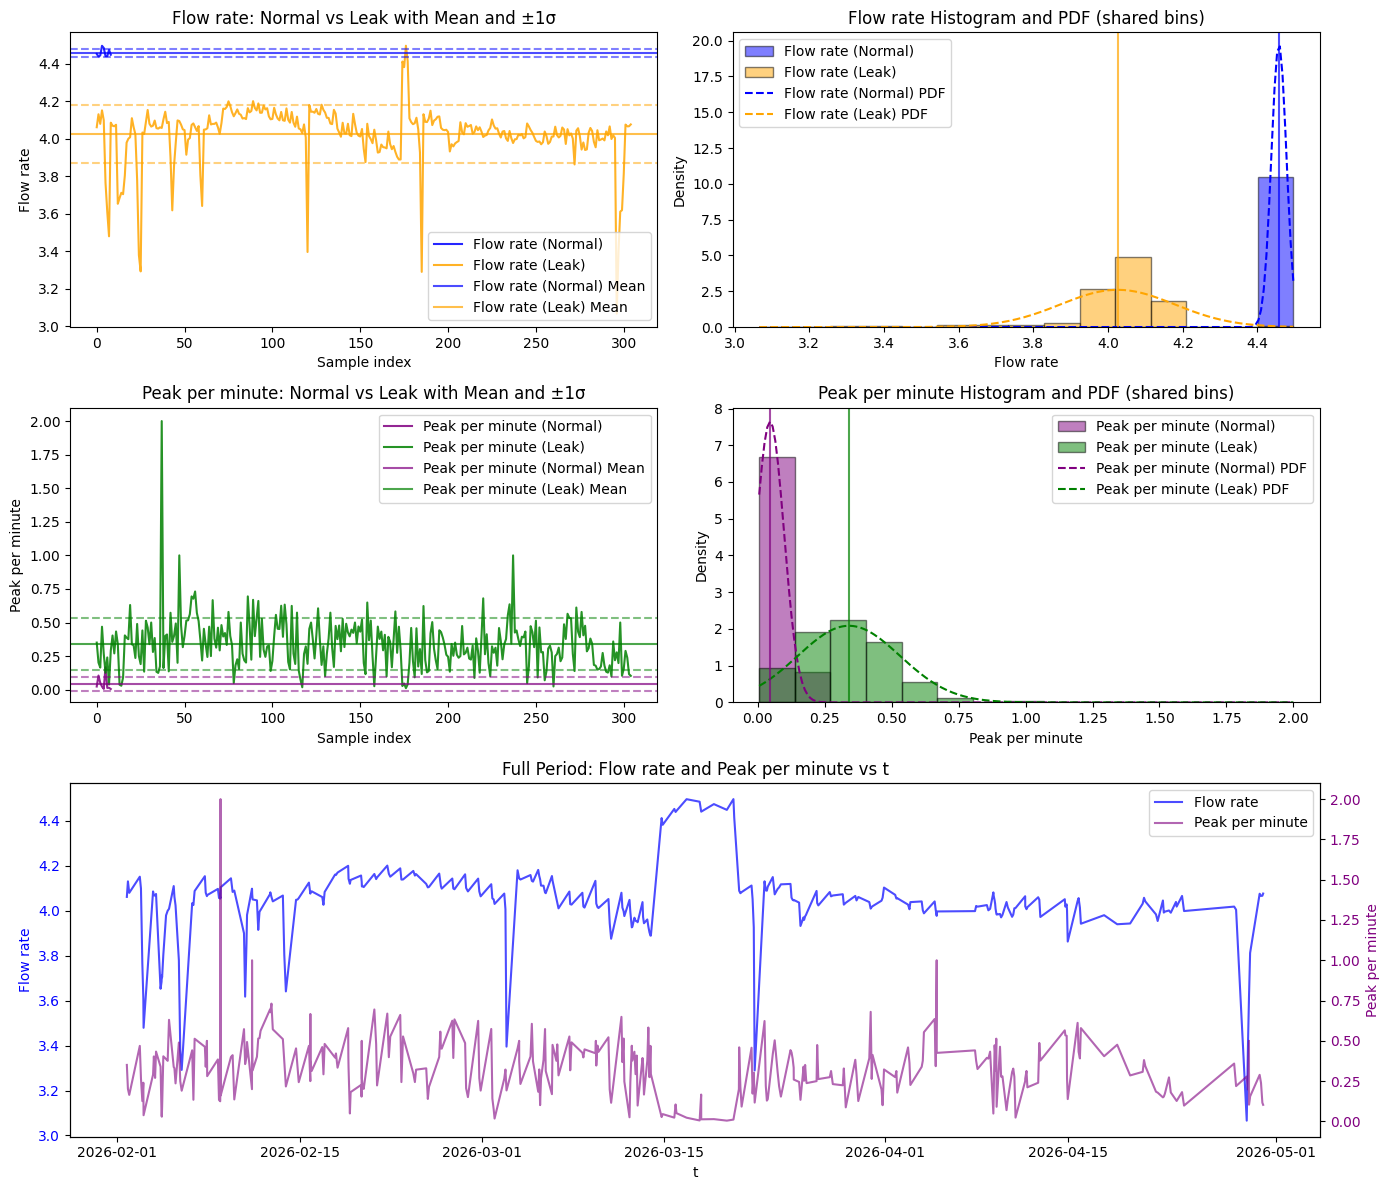

In [21]:
plot_feature_distributions_compare(Q1, Q2, Y1, Y2, t=t, Q=Q, Y=Y)

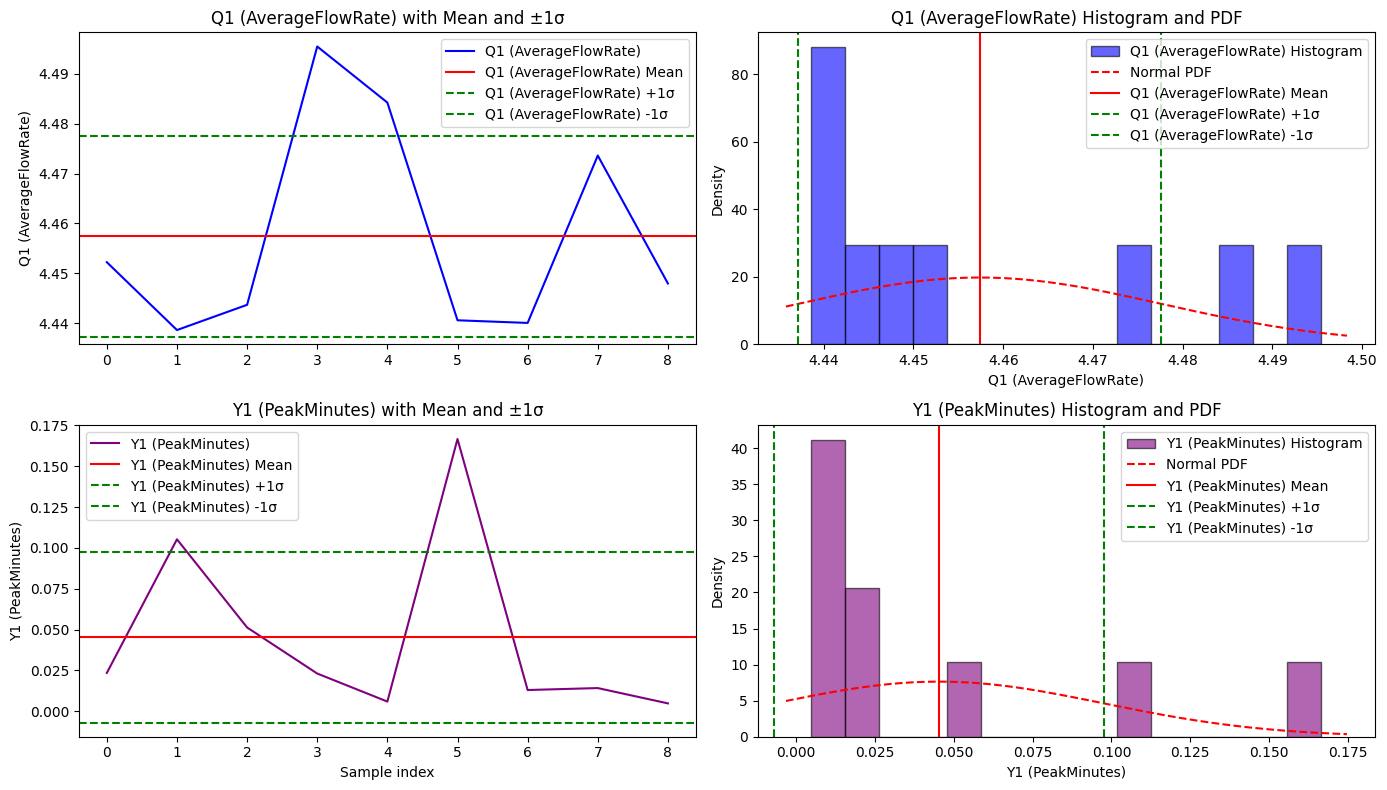

In [22]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_distributions(Q1, Y1, q1_label="Q1 (AverageFlowRate)", y1_label="Y1 (PeakMinutes)", bins=15, figsize=(14,8)):
    """
    Plot value traces with mean and ±1 sigma, plus histograms/PDFs, for given Q1 and Y1 arrays.
    Useful for situational testing in different Q and Y subgroups.

    Parameters:
    - Q1: Series or array-like for flow/quantity.
    - Y1: Series or array-like for peaks/minutes or other metric.
    - q1_label: Label for Q1 axis/legend.
    - y1_label: Label for Y1 axis/legend.
    - bins: Histogram bins.
    - figsize: Matplotlib figure size.
    """
    # Convert to numpy array if needed
    Q1_np = Q1.values if hasattr(Q1, "values") else np.asarray(Q1)
    Y1_np = Y1.values if hasattr(Y1, "values") else np.asarray(Y1)

    # Calculate mean and std for Q1 and Y1
    q1_mean, q1_std = Q1_np.mean(), Q1_np.std()
    y1_mean, y1_std = Y1_np.mean(), Y1_np.std()

    # Create normal distributions for Q1 and Y1
    q1_dist = norm(loc=q1_mean, scale=q1_std)
    y1_dist = norm(loc=y1_mean, scale=y1_std)

    # Plot Q1 and Y1 with their means and ±1 std deviation (sigma) bounds
    fig, axs = plt.subplots(2, 2, figsize=figsize)

    # Plot Q1
    axs[0, 0].plot(Q1_np, label=q1_label, color='b')
    axs[0, 0].axhline(q1_mean, color='r', linestyle='-', label=f'{q1_label} Mean')
    axs[0, 0].axhline(q1_mean + q1_std, color='g', linestyle='--', label=f'{q1_label} +1σ')
    axs[0, 0].axhline(q1_mean - q1_std, color='g', linestyle='--', label=f'{q1_label} -1σ')
    axs[0, 0].set_ylabel(q1_label)
    axs[0, 0].legend()
    axs[0, 0].set_title(f"{q1_label} with Mean and ±1σ")

    # Histogram of Q1
    axs[0, 1].hist(Q1_np, bins=bins, color='b', alpha=0.6, edgecolor='black', density=True, label=f"{q1_label} Histogram")
    xlim_q1 = axs[0, 1].get_xlim()
    x_vals_q1 = np.linspace(xlim_q1[0], xlim_q1[1], 200)
    axs[0, 1].plot(x_vals_q1, q1_dist.pdf(x_vals_q1), 'r--', label='Normal PDF')
    axs[0, 1].axvline(q1_mean, color='r', linestyle='-', label=f'{q1_label} Mean')
    axs[0, 1].axvline(q1_mean + q1_std, color='g', linestyle='--', label=f'{q1_label} +1σ')
    axs[0, 1].axvline(q1_mean - q1_std, color='g', linestyle='--', label=f'{q1_label} -1σ')
    axs[0, 1].set_title(f'{q1_label} Histogram and PDF')
    axs[0, 1].set_xlabel(q1_label)
    axs[0, 1].set_ylabel('Density')
    axs[0, 1].legend()

    # Plot Y1
    axs[1, 0].plot(Y1_np, label=y1_label, color='purple')
    axs[1, 0].axhline(y1_mean, color='r', linestyle='-', label=f'{y1_label} Mean')
    axs[1, 0].axhline(y1_mean + y1_std, color='g', linestyle='--', label=f'{y1_label} +1σ')
    axs[1, 0].axhline(y1_mean - y1_std, color='g', linestyle='--', label=f'{y1_label} -1σ')
    axs[1, 0].set_ylabel(y1_label)
    axs[1, 0].set_xlabel("Sample index")
    axs[1, 0].legend()
    axs[1, 0].set_title(f"{y1_label} with Mean and ±1σ")

    # Histogram of Y1
    axs[1, 1].hist(Y1_np, bins=bins, color='purple', alpha=0.6, edgecolor='black', density=True, label=f"{y1_label} Histogram")
    xlim_y1 = axs[1, 1].get_xlim()
    x_vals_y1 = np.linspace(xlim_y1[0], xlim_y1[1], 200)
    axs[1, 1].plot(x_vals_y1, y1_dist.pdf(x_vals_y1), 'r--', label='Normal PDF')
    axs[1, 1].axvline(y1_mean, color='r', linestyle='-', label=f'{y1_label} Mean')
    axs[1, 1].axvline(y1_mean + y1_std, color='g', linestyle='--', label=f'{y1_label} +1σ')
    axs[1, 1].axvline(y1_mean - y1_std, color='g', linestyle='--', label=f'{y1_label} -1σ')
    axs[1, 1].set_title(f'{y1_label} Histogram and PDF')
    axs[1, 1].set_xlabel(y1_label)
    axs[1, 1].set_ylabel('Density')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

# Example usage (uncomment to test in the notebook context):
plot_feature_distributions(Q1, Y1)


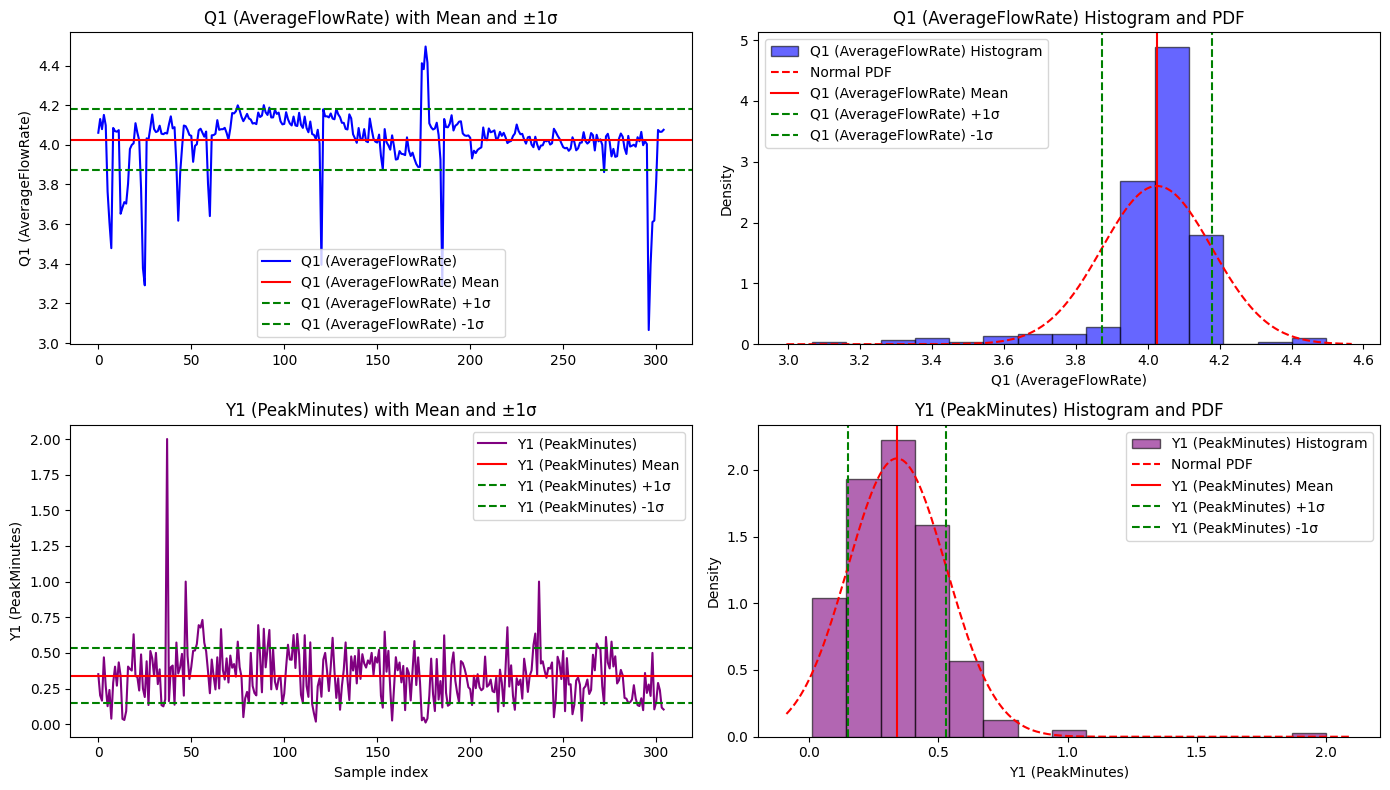

In [23]:
plot_feature_distributions(Q2, Y2)

In [24]:
Q_norm = (Q - np.mean(Q)) / np.std(Q)
Y_norm = (Y - np.mean(Y)) / np.std(Y)
dQ = np.gradient(Q_norm)

dY = np.gradient(Y_norm)

X = np.column_stack([Q_norm, dQ, Y_norm, dY])

In [25]:
cp_probs, R = bocpd_multivariate(X, hazard=1 / 100)


NameError: name 'alarm' is not defined

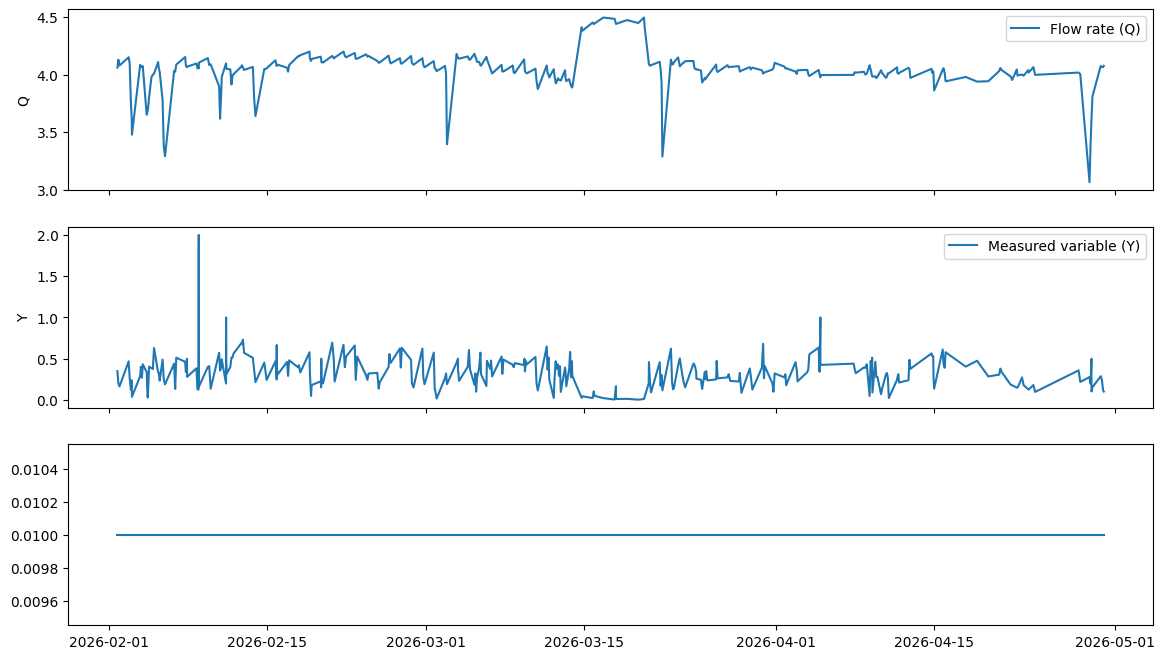

In [26]:
fig, ax = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
ax[0].plot(t,Q, label="Flow rate (Q)")
ax[0].set_ylabel("Q")
ax[0].legend()


ax[1].plot(t,Y, label="Measured variable (Y)")
ax[1].set_ylabel("Y")
ax[1].legend()


ax[2].plot(t,cp_probs, label="Run-length drop score")
#plt.axvline(true_cp, color="red", linestyle="--", label="True leak start")
alarm_idx = np.where(alarm)[0]

plt.tight_layout()
plt.show()
if len(alarm_idx) > 0:
    print(f"Alarm first triggered at t={alarm_idx[0]}")
else:
    print("No alarm triggered")